# 准备工作

In [1]:
#  Setup

import polars as pl
from pathlib import Path

# Display settings
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(50)

# Project paths
PROJECT_DIR = Path(r"C:\Users\71907\Documents\Work\Project")
CLEANED_DIR = PROJECT_DIR / "cleaned_data"

# Main datasets needed for the first EDA section
STUDENT_INFO_PATH = CLEANED_DIR / "student_info_clean.parquet"

print("Student info file exists:", STUDENT_INFO_PATH.exists())

Student info file exists: True


In [2]:
# Load student_info

student_info = pl.read_parquet(STUDENT_INFO_PATH)

print("Shape:", student_info.shape)
student_info.head()

Shape: (32593, 12)


code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
str,str,i64,str,str,str,str,str,i64,i64,str,str
"""AAA""","""2013J""",11391,"""M""","""East Anglian Region""","""HE Qualification""","""90-100%""","""55<=""",0,240,"""N""","""Pass"""
"""AAA""","""2013J""",28400,"""F""","""Scotland""","""HE Qualification""","""20-30%""","""35-55""",0,60,"""N""","""Pass"""
"""AAA""","""2013J""",30268,"""F""","""North Western Region""","""A Level or Equivalent""","""30-40%""","""35-55""",0,60,"""Y""","""Withdrawn"""
"""AAA""","""2013J""",31604,"""F""","""South East Region""","""A Level or Equivalent""","""50-60%""","""35-55""",0,60,"""N""","""Pass"""
"""AAA""","""2013J""",32885,"""F""","""West Midlands Region""","""Lower Than A Level""","""50-60%""","""0-35""",0,60,"""N""","""Pass"""


In [3]:
# 检查 schema 和 final_result

student_info.select(
    [
        "code_module",
        "code_presentation",
        "id_student",
        "final_result",
    ]
).schema

Schema([('code_module', String),
        ('code_presentation', String),
        ('id_student', Int64),
        ('final_result', String)])

# 3.1 Student Outcome Distribution

In [4]:
# Overall count and percentage

outcome_distribution = (
    student_info
    .group_by("final_result")
    .agg(
        pl.len().alias("n_students")
    )
    .with_columns(
        (
            pl.col("n_students") / pl.col("n_students").sum() * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("n_students", descending=True)
)

outcome_distribution

final_result,n_students,percentage
str,u32,f64
"""Pass""",12361,37.93
"""Withdrawn""",10156,31.16
"""Fail""",7052,21.64
"""Distinction""",3024,9.28


In [5]:
# validation

outcome_validation = student_info.select(
    pl.len().alias("total_rows"),
    pl.col("final_result").null_count().alias("missing_final_result"),
    pl.col("final_result").n_unique().alias("n_outcome_classes"),
)

outcome_validation

total_rows,missing_final_result,n_outcome_classes
u32,u32,u32
32593,0,4


In [6]:
# category values

student_info.select(
    pl.col("final_result").unique().sort()
)

final_result
str
"""Distinction"""
"""Fail"""
"""Pass"""
"""Withdrawn"""


这组结果用于确认：

multiclass target 是否确实包含
Distinction / Pass / Fail / Withdrawn

是否存在 missing target

class imbalance 的程度

后续 evaluation 是否需要重点使用 macro F1、per-class recall 和 confusion matrix，而不能只依赖 accuracy

↑ 结果解释:

Pass 是最大类别，占 37.93%

Withdrawn 占 31.16%

Fail 占 21.64%

Distinction 最少，占 9.28%

final_result 没有 missing values

四个 multiclass categories 完整保留

这说明存在明显但不极端的 class imbalance。尤其是 Distinction 明显少于其他类别，因此后续不能只使用 accuracy，还应关注：

macro F1

per-class precision

per-class recall

confusion matrix

同时，Withdrawn 占比超过 30%，说明它不是小型异常类别，而是 outcome representation 中的重要组成部分，也支持你后续比较：

Multiclass classification
vs
Two-stage classification

In [7]:
# 制作一个 outcome distribution bar chart

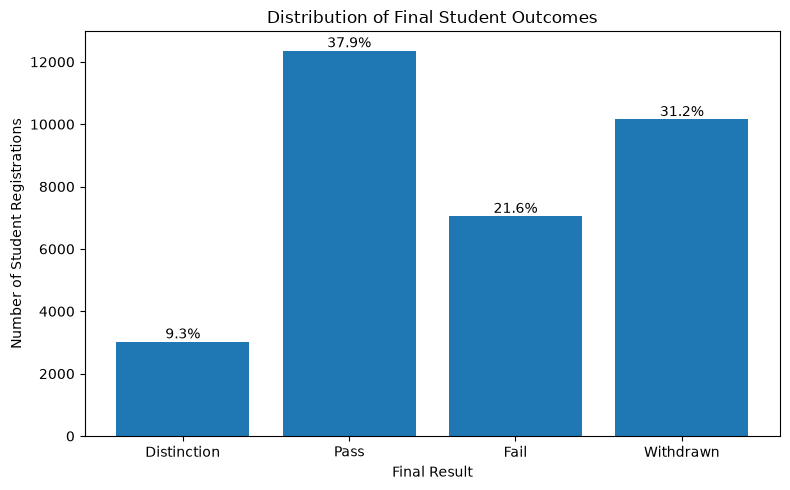

In [8]:
import matplotlib.pyplot as plt

outcome_order = [
    "Distinction",
    "Pass",
    "Fail",
    "Withdrawn",
]

outcome_plot_data = (
    outcome_distribution
    .with_columns(
        pl.col("final_result")
        .cast(
            pl.Enum(outcome_order)
        )
    )
    .sort("final_result")
)

labels = outcome_plot_data["final_result"].to_list()
counts = outcome_plot_data["n_students"].to_list()
percentages = outcome_plot_data["percentage"].to_list()

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, counts)

plt.title("Distribution of Final Student Outcomes")
plt.xlabel("Final Result")
plt.ylabel("Number of Student Registrations")

for bar, percentage in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

这张图直接展示 prediction target 的类别结构和 class imbalance，后续可以用于解释 evaluation metric 的选

这个 subsection 暂时只需要这一张图，不需要再做 pie chart。

In [9]:
# 检查 module–presentation differences

outcome_by_presentation = (
    student_info
    .group_by(
        [
            "code_module",
            "code_presentation",
            "final_result",
        ]
    )
    .agg(
        pl.len().alias("n_students")
    )
    .with_columns(
        pl.col("n_students")
        .sum()
        .over(["code_module", "code_presentation"])
        .alias("presentation_total")
    )
    .with_columns(
        (
            pl.col("n_students")
            / pl.col("presentation_total")
            * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort(
        [
            "code_module",
            "code_presentation",
            "final_result",
        ]
    )
)

outcome_by_presentation

code_module,code_presentation,final_result,n_students,presentation_total,percentage
str,str,str,u32,u32,f64
"""AAA""","""2013J""","""Distinction""",20,383,5.22
"""AAA""","""2013J""","""Fail""",45,383,11.75
"""AAA""","""2013J""","""Pass""",258,383,67.36
"""AAA""","""2013J""","""Withdrawn""",60,383,15.67
"""AAA""","""2014J""","""Distinction""",24,365,6.58
"""AAA""","""2014J""","""Fail""",46,365,12.6
"""AAA""","""2014J""","""Pass""",229,365,62.74
"""AAA""","""2014J""","""Withdrawn""",66,365,18.08
"""BBB""","""2013B""","""Distinction""",155,1767,8.77


先只做 table，不画更多图。目的是判断不同 course cohorts 的 outcome composition 是否明显不同，以及后续 train/test split 是否需要保留 module–presentation structure

In [10]:
# 为了更容易阅读，再生成一个 wide table
 
outcome_by_presentation_wide = (
    outcome_by_presentation
    .select(
        [
            "code_module",
            "code_presentation",
            "final_result",
            "percentage",
        ]
    )
    .pivot(
        on="final_result",
        index=["code_module", "code_presentation"],
        values="percentage",
    )
    .sort(["code_module", "code_presentation"])
)

outcome_by_presentation_wide

code_module,code_presentation,Distinction,Fail,Pass,Withdrawn
str,str,f64,f64,f64,f64
"""AAA""","""2013J""",5.22,11.75,67.36,15.67
"""AAA""","""2014J""",6.58,12.6,62.74,18.08
"""BBB""","""2013B""",8.77,25.98,36.67,28.58
"""BBB""","""2013J""",7.87,23.29,40.05,28.79
"""BBB""","""2014B""",10.29,24.55,34.78,30.38
"""BBB""","""2014J""",7.85,17.06,42.41,32.68
"""CCC""","""2014B""",9.92,19.37,24.33,46.38
"""CCC""","""2014J""",12.25,16.25,28.38,43.11
"""DDD""","""2013B""",4.14,27.71,35.0,33.15


这个 table 已经说明 module–presentation 之间存在明显的 outcome composition differences，但没有看到 data error。

几个主要 pattern：

AAA 的 Pass 很高，约 63%–67%，Withdrawn 和 Fail 都相对低。

CCC 的 Withdrawn 特别高，约 43%–46%，而 Pass 只有约 24%–28%。

GGG 的 Withdrawn 很低，约 7%–17%，但 Fail 相对较高。

Distinction 在大多数 cohorts 中仍然是较小类别，但比例并不完全一致，大约从 4% 到 17%。

这说明 overall outcome distribution 会掩盖明显的 module/presentation heterogeneity。

后续 modelling 时，code_module 和 code_presentation 不能被忽略；

evaluation 也最好检查模型是否只是学到了不同 cohorts 的 baseline outcome rates。

不过这一部分不需要再画额外图。建议保留：

overall outcome bar chart

这个 wide table 作为 notebook 中的 supporting check

In [11]:
# 做一个简短 summary table

outcome_percentage_range = (
    outcome_by_presentation
    .group_by("final_result")
    .agg(
        pl.col("percentage").min().alias("minimum_percentage"),
        pl.col("percentage").max().alias("maximum_percentage"),
        pl.col("percentage").mean().round(2).alias("mean_percentage"),
    )
    .with_columns(
        (
            pl.col("maximum_percentage")
            - pl.col("minimum_percentage")
        )
        .round(2)
        .alias("percentage_point_range")
    )
    .sort("final_result")
)

outcome_percentage_range

final_result,minimum_percentage,maximum_percentage,mean_percentage,percentage_point_range
str,f64,f64,f64,f64
"""Distinction""",4.14,16.96,9.55,12.82
"""Fail""",11.75,30.88,21.7,19.13
"""Pass""",24.33,67.36,40.6,43.03
"""Withdrawn""",6.93,46.38,28.15,39.45


结果确认了 module–presentation heterogeneity 很明显：

Pass 的 cohort range 最大：24.33%–67.36%

Withdrawn 也有较大差异：6.93%–46.38%

Fail：11.75%–30.88%

Distinction 相对更稳定，但仍为 4.14%–16.96%

注意，mean_percentage 是对各 module–presentation 等权平均，不是 overall percentage，所以不应拿它替代前面的 overall outcome distribution。

# 3.2 Student Characteristics

In [12]:
# 检查主要 variables 的 missing values 和 category structure

characteristic_columns = [
    "gender",
    "age_band",
    "highest_education",
    "imd_band",
    "studied_credits",
    "num_of_prev_attempts",
    "disability",
]

student_info.select(characteristic_columns).schema

Schema([('gender', String),
        ('age_band', String),
        ('highest_education', String),
        ('imd_band', String),
        ('studied_credits', Int64),
        ('num_of_prev_attempts', Int64),
        ('disability', String)])

In [13]:
# missing-value summary

characteristics_missing = student_info.select(
    [
        pl.col(column).null_count().alias(column)
        for column in characteristic_columns
    ]
).unpivot(
    variable_name="variable",
    value_name="missing_count",
).with_columns(
    (
        pl.col("missing_count") / student_info.height * 100
    )
    .round(2)
    .alias("missing_percentage")
)

characteristics_missing

variable,missing_count,missing_percentage
str,u32,f64
"""gender""",0,0.0
"""age_band""",0,0.0
"""highest_education""",0,0.0
"""imd_band""",0,0.0
"""studied_credits""",0,0.0
"""num_of_prev_attempts""",0,0.0
"""disability""",0,0.0


In [14]:
# categorical values
 
categorical_columns = [
    "gender",
    "age_band",
    "highest_education",
    "imd_band",
    "disability",
]

for column in categorical_columns:
    print(f"\n{column}")
    print(
        student_info
        .group_by(column)
        .agg(pl.len().alias("n_registrations"))
        .with_columns(
            (
                pl.col("n_registrations") / student_info.height * 100
            )
            .round(2)
            .alias("percentage")
        )
        .sort("n_registrations", descending=True)
    )


gender
shape: (2, 3)
┌────────┬─────────────────┬────────────┐
│ gender ┆ n_registrations ┆ percentage │
│ ---    ┆ ---             ┆ ---        │
│ str    ┆ u32             ┆ f64        │
╞════════╪═════════════════╪════════════╡
│ M      ┆ 17875           ┆ 54.84      │
│ F      ┆ 14718           ┆ 45.16      │
└────────┴─────────────────┴────────────┘

age_band
shape: (3, 3)
┌──────────┬─────────────────┬────────────┐
│ age_band ┆ n_registrations ┆ percentage │
│ ---      ┆ ---             ┆ ---        │
│ str      ┆ u32             ┆ f64        │
╞══════════╪═════════════════╪════════════╡
│ 0-35     ┆ 22944           ┆ 70.4       │
│ 35-55    ┆ 9433            ┆ 28.94      │
│ 55<=     ┆ 216             ┆ 0.66       │
└──────────┴─────────────────┴────────────┘

highest_education
shape: (5, 3)
┌─────────────────────────────┬─────────────────┬────────────┐
│ highest_education           ┆ n_registrations ┆ percentage │
│ ---                         ┆ ---             ┆ ---        │


目前可以先确认三点：

这 7 个 variables 都没有 missing values。

gender 比较均衡：M 54.84%，F 45.16%。

age_band 明显集中在 0-35，占 70.40%；55<= 只有 0.66%，属于很小的 subgroup。

最后贴出的 N / Y 应该是 disability，不是 highest_education：N 90.29%，Y 9.71%。

In [15]:
for column in ["highest_education", "imd_band", "disability"]:
    print(f"\n{column}")

    result = (
        student_info
        .group_by(column)
        .agg(pl.len().alias("n_registrations"))
        .with_columns(
            (
                pl.col("n_registrations") / student_info.height * 100
            )
            .round(2)
            .alias("percentage")
        )
        .sort("n_registrations", descending=True)
    )

    print(result)


highest_education
shape: (5, 3)
┌─────────────────────────────┬─────────────────┬────────────┐
│ highest_education           ┆ n_registrations ┆ percentage │
│ ---                         ┆ ---             ┆ ---        │
│ str                         ┆ u32             ┆ f64        │
╞═════════════════════════════╪═════════════════╪════════════╡
│ A Level or Equivalent       ┆ 14045           ┆ 43.09      │
│ Lower Than A Level          ┆ 13158           ┆ 40.37      │
│ HE Qualification            ┆ 4730            ┆ 14.51      │
│ No Formal quals             ┆ 347             ┆ 1.06       │
│ Post Graduate Qualification ┆ 313             ┆ 0.96       │
└─────────────────────────────┴─────────────────┴────────────┘

imd_band
shape: (11, 3)
┌──────────┬─────────────────┬────────────┐
│ imd_band ┆ n_registrations ┆ percentage │
│ ---      ┆ ---             ┆ ---        │
│ str      ┆ u32             ┆ f64        │
╞══════════╪═════════════════╪════════════╡
│ 20-30%   ┆ 3654            

目前可以先确认：

highest_education 主要集中在：

A Level or Equivalent: 43.09%

Lower Than A Level: 40.37%

HE Qualification 占 14.51%

No Formal quals 和 Post Graduate Qualification 都非常少

disability 明显不均衡：
N: 90.29% + 
Y: 9.71%

In [16]:
imd_distribution = (
    student_info
    .group_by("imd_band")
    .agg(pl.len().alias("n_registrations"))
    .with_columns(
        (
            pl.col("n_registrations") / student_info.height * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("imd_band")
)

imd_distribution

imd_band,n_registrations,percentage
str,u32,f64
"""0-10%""",3311,10.16
"""10-20%""",3516,10.79
"""20-30%""",3654,11.21
"""30-40%""",3539,10.86
"""40-50%""",3256,9.99
"""50-60%""",3124,9.58
"""60-70%""",2905,8.91
"""70-80%""",2879,8.83
"""80-90%""",2762,8.47


imd_band 分布整体比较均匀，没有某一个 category 占据绝大多数样本：

各已知 bands 大约占 7.78%–11.21%

Unknown 占 3.41%

较低 IMD bands 的比例略高，但差异不算极端

这里的 Unknown 是之前 cleaning 后保留的 category，不是当前仍存在的 missing value。

目前 3.2 已经确认的 sample composition 是：

gender 相对均衡

大多数 registrations 来自 0-35 age group

highest_education 主要为 A Level or Equivalent 和 Lower Than A Level

disability = Y 是较小 subgroup

imd_band 分布较分散

In [17]:
# 检查两个 numeric variables :
# studied_credits + num_of_prev_attempts

# 先运行 descriptive statistics:

numeric_characteristics_summary = student_info.select(
    [
        pl.col("studied_credits").min().alias("credits_min"),
        pl.col("studied_credits").quantile(0.25).alias("credits_q1"),
        pl.col("studied_credits").median().alias("credits_median"),
        pl.col("studied_credits").mean().round(2).alias("credits_mean"),
        pl.col("studied_credits").quantile(0.75).alias("credits_q3"),
        pl.col("studied_credits").max().alias("credits_max"),

        pl.col("num_of_prev_attempts").min().alias("attempts_min"),
        pl.col("num_of_prev_attempts").median().alias("attempts_median"),
        pl.col("num_of_prev_attempts").mean().round(2).alias("attempts_mean"),
        pl.col("num_of_prev_attempts").max().alias("attempts_max"),
    ]
)

numeric_characteristics_summary

credits_min,credits_q1,credits_median,credits_mean,credits_q3,credits_max,attempts_min,attempts_median,attempts_mean,attempts_max
i64,f64,f64,f64,f64,i64,i64,f64,f64,i64
30,60.0,60.0,79.76,120.0,655,0,0.0,0.16,6


结果说明：

studied_credits 主要集中在 60–120 credits

median 是 60，mean 是 79.76，说明分布明显 right-skewed

最大值 655 很高，但目前只能视为 legitimate unusual record，不能直接当作 data error 或删除

num_of_prev_attempts 的 median 为 0、mean 为 0.16，和前面的 frequency table 一致

In [18]:
# 再看 previous attempts 的 frequency

previous_attempts_distribution = (
    student_info
    .group_by("num_of_prev_attempts")
    .agg(pl.len().alias("n_registrations"))
    .with_columns(
        (
            pl.col("n_registrations") / student_info.height * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("num_of_prev_attempts")
)

previous_attempts_distribution

num_of_prev_attempts,n_registrations,percentage
i64,u32,f64
0,28421,87.2
1,3299,10.12
2,675,2.07
3,142,0.44
4,39,0.12
5,13,0.04
6,4,0.01


In [19]:
# 再看 previous attempts 的 frequency

previous_attempts_distribution = (
    student_info
    .group_by("num_of_prev_attempts")
    .agg(pl.len().alias("n_registrations"))
    .with_columns(
        (
            pl.col("n_registrations") / student_info.height * 100
        )
        .round(2)
        .alias("percentage")
    )
    .sort("num_of_prev_attempts")
)

previous_attempts_distribution

num_of_prev_attempts,n_registrations,percentage
i64,u32,f64
0,28421,87.2
1,3299,10.12
2,675,2.07
3,142,0.44
4,39,0.12
5,13,0.04
6,4,0.01


这个分布很清楚：

87.20% 的 registrations 没有 previous attempt

10.12% 有 1 次 previous attempt

只有 2.68% 有 2 次或以上 previous attempts

最大值为 6，但高次数 observations 很少

因此，num_of_prev_attempts 是一个明显 right-skewed variable，大部分 students 都集中在 0。这里不是 data error，较高次数属于 legitimate unusual records，暂时不需要删除或合并。

对 dissertation 来说，这个结果说明 num_of_prev_attempts 可能反映 prior study history，但不值得单独制作一张图。后续只需要比较不同 final_result groups 的平均值或有无 previous attempt 的比例。

这一步是为了判断：

studied_credits 是否存在较强 skewness 或 unusual high values

大多数 students 是否是首次修读

这两个 variables 是否值得进一步按 final_result 比较

In [20]:
# 比较不同 final_result groups 的 student characteristics

characteristics_by_outcome = (
    student_info
    .group_by("final_result")
    .agg(
        pl.len().alias("n_registrations"),

        pl.col("studied_credits")
        .median()
        .alias("median_studied_credits"),

        pl.col("studied_credits")
        .mean()
        .round(2)
        .alias("mean_studied_credits"),

        pl.col("num_of_prev_attempts")
        .mean()
        .round(2)
        .alias("mean_previous_attempts"),

        (
            (pl.col("num_of_prev_attempts") > 0)
            .mean()
            * 100
        )
        .round(2)
        .alias("previous_attempt_percentage"),

        (
            (pl.col("disability") == "Y")
            .mean()
            * 100
        )
        .round(2)
        .alias("disability_percentage"),
    )
    .sort("final_result")
)

characteristics_by_outcome

final_result,n_registrations,median_studied_credits,mean_studied_credits,mean_previous_attempts,previous_attempt_percentage,disability_percentage
str,u32,f64,f64,f64,f64,f64
"""Distinction""",3024,60.0,71.76,0.06,5.52,7.37
"""Fail""",7052,60.0,76.09,0.25,18.73,10.1
"""Pass""",12361,60.0,74.22,0.12,9.81,7.96
"""Withdrawn""",10156,60.0,91.43,0.19,14.48,12.26


结果有几个比较清楚的 descriptive differences：

四组的 median_studied_credits 都是 60，说明 typical workload 相近。

Withdrawn 的 mean studied credits 最高，为 91.43；但由于 median 相同，这更可能由较高值拉动，不能直接解释为所有 withdrawn students 都修读更多 credits。

Fail 的 previous attempt percentage 最高，为 18.73%，其次是 Withdrawn 的 14.48%。

Distinction 的 previous attempt percentage 最低，仅 5.52%。

Withdrawn group 的 disability percentage 最高，为 12.26%；Distinction 最低，为 7.37%。

这些只能写成 associations / descriptive differences，不能写成 causal effects。

In [21]:
# 检查 categorical characteristics 与 outcome
# 为了判断正文 paragraph 是否需要提到 age_band 或 highest_education，先只生成一个 compact percentage table 

categorical_outcome_summary = (
    student_info
    .group_by("final_result")
    .agg(
        (
            (pl.col("gender") == "F").mean() * 100
        ).round(2).alias("female_percentage"),

        (
            (pl.col("age_band") == "0-35").mean() * 100
        ).round(2).alias("age_0_35_percentage"),

        (
            (pl.col("highest_education") == "Lower Than A Level").mean() * 100
        ).round(2).alias("lower_than_a_level_percentage"),

        (
            pl.col("imd_band")
            .is_in(["0-10%", "10-20%"])
            .mean() * 100
        ).round(2).alias("lowest_imd_20_percentage"),
    )
    .sort("final_result")
)

categorical_outcome_summary

final_result,female_percentage,age_0_35_percentage,lower_than_a_level_percentage,lowest_imd_20_percentage
str,f64,f64,f64,f64
"""Distinction""",46.1,61.61,24.04,11.87
"""Fail""",44.0,74.18,48.58,25.92
"""Pass""",46.4,68.51,35.47,17.5
"""Withdrawn""",44.17,72.68,45.49,24.39


这个结果说明，gender 在四个 outcome groups 之间差异很小，不值得在正文中特别展开。更明显的是：

Fail 和 Withdrawn 中 0-35 students 的比例更高，分别为 74.18% 和 72.68%。

Lower Than A Level 在 Fail 中占 48.58%，在 Withdrawn 中占 45.49%，明显高于 Pass 的 35.47% 和 Distinction 的 24.04%。

lowest 20% imd_band 在 Fail 和 Withdrawn 中也更常见，分别为 25.92% 和 24.39%，而 Distinction 中只有 11.87%。

这些属于 descriptive associations，不能写成这些 characteristics 导致某种 outcome。

In [22]:
# 生成最终 table

student_characteristics_table = (
    characteristics_by_outcome
    .join(
        categorical_outcome_summary,
        on="final_result",
        how="inner",
    )
    .select(
        [
            "final_result",
            "mean_studied_credits",
            "previous_attempt_percentage",
            "disability_percentage",
            "lower_than_a_level_percentage",
            "lowest_imd_20_percentage",
        ]
    )
    .sort("final_result")
)

student_characteristics_table

final_result,mean_studied_credits,previous_attempt_percentage,disability_percentage,lower_than_a_level_percentage,lowest_imd_20_percentage
str,f64,f64,f64,f64,f64
"""Distinction""",71.76,5.52,7.37,24.04,11.87
"""Fail""",76.09,18.73,10.1,48.58,25.92
"""Pass""",74.22,9.81,7.96,35.47,17.5
"""Withdrawn""",91.43,14.48,12.26,45.49,24.39


# 3.3 Assessment Patterns

In [23]:
# 读取三个dateset

ASSESSMENTS_PATH = CLEANED_DIR / "assessments_clean.parquet"
STUDENT_ASSESSMENT_PATH = CLEANED_DIR / "student_assessment_clean.parquet"

assessments = pl.read_parquet(ASSESSMENTS_PATH)
student_assessment = pl.read_parquet(STUDENT_ASSESSMENT_PATH)

print("assessments shape:", assessments.shape)
print("student_assessment shape:", student_assessment.shape)

assessments shape: (206, 6)
student_assessment shape: (173912, 7)


In [24]:
# 检查 assessment types 和 missing score

assessment_structure = (
    assessments
    .group_by("assessment_type")
    .agg(
        pl.len().alias("n_assessments"),
        pl.col("date").null_count().alias("missing_assessment_dates"),
    )
    .sort("assessment_type")
)

assessment_structure

assessment_type,n_assessments,missing_assessment_dates
str,u32,u32
"""CMA""",76,0
"""Exam""",24,11
"""TMA""",106,0


In [25]:
score_missing_summary = student_assessment.select(
    pl.len().alias("n_submission_records"),
    pl.col("score").null_count().alias("missing_scores"),
    (
        pl.col("score").null_count() / pl.len() * 100
    )
    .round(3)
    .alias("missing_score_percentage"),
    pl.col("score").min().alias("minimum_score"),
    pl.col("score").median().alias("median_score"),
    pl.col("score").mean().round(2).alias("mean_score"),
    pl.col("score").max().alias("maximum_score"),
)

score_missing_summary

n_submission_records,missing_scores,missing_score_percentage,minimum_score,median_score,mean_score,maximum_score
u32,u32,f64,i64,f64,f64,i64
173912,173,0.099,0,80.0,75.8,100


结果正常，没有发现新的 data issue：

CMA：76 个，date 无 missing

TMA：106 个，date 无 missing

Exam：24 个，其中 11 个 date missing，和之前确认的 structural missingness 一致

一共 173,912 条 submission records

只有 173 个 missing scores，占 0.099%

score 范围为 0–100

median 为 80，mean 为 75.80

mean 低于 median，说明 score distribution 可能有一定 left-skewness，低分 records 拉低了平均值。不过先不要仅凭这两个数下正式结论，后面看 distribution 再确认。

这一组 checks 用来确认：

TMA、CMA、Exam 的数量结构；

missing assessment dates 是否仍然只来自 Exam；

missing scores 的比例是否很小；

score distribution 的基本范围是否合理。

In [26]:
# join assessment metadata 和 final result

# 把每条 submission 对应到
# assessment_type
# assessment_date
# final_result

assessment_eda = (
    student_assessment
    .join(
        assessments.select(
            [
                "id_assessment",
                "code_module",
                "code_presentation",
                "assessment_type",
                "date",
                "weight",
            ]
        ),
        on="id_assessment",
        how="left",
        validate="m:1",
    )
    .join(
        student_info.select(
            [
                "code_module",
                "code_presentation",
                "id_student",
                "final_result",
            ]
        ),
        on=[
            "code_module",
            "code_presentation",
            "id_student",
        ],
        how="left",
        validate="m:1",
    )
)

print("Joined shape:", assessment_eda.shape)

Joined shape: (173912, 13)


In [27]:
assessment_join_validation = assessment_eda.select(
    pl.len().alias("total_rows"),
    pl.col("assessment_type")
    .null_count()
    .alias("missing_assessment_match"),
    pl.col("final_result")
    .null_count()
    .alias("missing_student_match"),
)

assessment_join_validation

total_rows,missing_assessment_match,missing_student_match
u32,u32,u32
173912,0,0


In [28]:
score_by_assessment_type = (
    assessment_eda
    .group_by("assessment_type")
    .agg(
        pl.len().alias("n_submission_records"),
        pl.col("score").null_count().alias("missing_scores"),
        pl.col("score").median().alias("median_score"),
        pl.col("score").mean().round(2).alias("mean_score"),
        pl.col("score").min().alias("minimum_score"),
        pl.col("score").max().alias("maximum_score"),
    )
    .sort("assessment_type")
)

score_by_assessment_type

assessment_type,n_submission_records,missing_scores,median_score,mean_score,minimum_score,maximum_score
str,u32,u32,f64,f64,i64,i64
"""CMA""",70527,0,82.0,81.03,0,100
"""Exam""",4959,0,67.0,65.57,0,100
"""TMA""",98426,173,76.0,72.56,0,100


join 完全正常：

173,912 rows 全部匹配到 assessment metadata

全部匹配到 final_result

没有 join-related missingness

score_by_assessment_type 也显示出明显差异：

CMA：median 82，mean 81.03

TMA：median 76，mean 72.56

Exam：median 67，mean 65.57

173 个 missing scores 全部出现在 TMA

这些差异不能直接解释为某种 assessment type 更容易，因为不同 modules、assessment designs 和参与学生可能不同。目前只作为 descriptive pattern。

In [29]:
# 不同 final_result 的 assessment performance

# 先计算每个 student registration 的 assessment summary，再按 final_result 汇总。不能直接对所有 submission rows 求平均，否则提交次数多的 students 会获得更高权重。

student_assessment_summary = (
    assessment_eda
    .group_by(
        [
            "code_module",
            "code_presentation",
            "id_student",
            "final_result",
        ]
    )
    .agg(
        pl.col("score")
        .mean()
        .round(2)
        .alias("mean_assessment_score"),

        pl.col("score")
        .median()
        .alias("median_assessment_score"),

        pl.col("score")
        .count()
        .alias("n_scored_submissions"),

        pl.col("score")
        .null_count()
        .alias("n_missing_scores"),

        pl.col("date_submitted")
        .mean()
        .round(2)
        .alias("mean_submission_day"),
    )
)

print("Student-level assessment rows:", student_assessment_summary.height)

Student-level assessment rows: 25843


In [30]:
# outcome汇总

assessment_by_outcome = (
    student_assessment_summary
    .group_by("final_result")
    .agg(
        pl.len().alias("n_students_with_submission"),

        pl.col("mean_assessment_score")
        .median()
        .alias("median_student_mean_score"),

        pl.col("mean_assessment_score")
        .mean()
        .round(2)
        .alias("mean_student_mean_score"),

        pl.col("n_scored_submissions")
        .median()
        .alias("median_scored_submissions"),

        pl.col("mean_submission_day")
        .median()
        .alias("median_mean_submission_day"),
    )
    .sort("final_result")
)

assessment_by_outcome

final_result,n_students_with_submission,median_student_mean_score,mean_student_mean_score,median_scored_submissions,median_mean_submission_day
str,u32,f64,f64,f64,f64
"""Distinction""",3024,89.42,88.49,9.0,118.72
"""Fail""",5768,65.92,64.23,4.0,73.0
"""Pass""",12358,77.86,76.18,9.0,118.08
"""Withdrawn""",4693,68.0,64.11,2.0,39.0


结果很有信息量，也和你的 dissertation 方向相关：

Distinction 的 student-level mean score 最高，median 为 89.42

Pass 次之，median 为 77.86

Fail 和 Withdrawn 较低，分别为 65.92 和 68.00

Distinction 和 Pass 的 median scored submissions 都是 9

Fail 只有 4

Withdrawn 只有 2

Withdrawn 的 median mean submission day 只有 39，明显早于其他 groups，说明很多 withdrawn students 很早就停止产生 assessment records

不过这里要特别注意：

median_mean_submission_day 不是“平均是否 late submission”

它主要反映每个学生现有 submission records 出现在课程时间线的哪个位置

对 Withdrawn 来说，较早的数值很可能是因为他们较早停止参与，而不是因为他们更早完成 assessments

另外，只有 25,843 个 student registrations 有 assessment submissions，而总样本是 32,593。

也就是说还有 6,750 个 registrations 没有任何 assessment record。这很可能主要集中在 Withdrawn 和部分 Fail，值得单独检查，因为“没有 submission”本身可能是很重要的 early behavior signal。

In [31]:
# 检查没有 assessment submission 的 outcome composition

assessment_participation = (
    student_info
    .join(
        student_assessment_summary.select(
            [
                "code_module",
                "code_presentation",
                "id_student",
            ]
        ).with_columns(
            pl.lit(1).alias("has_assessment_submission")
        ),
        on=[
            "code_module",
            "code_presentation",
            "id_student",
        ],
        how="left",
    )
    .with_columns(
        pl.col("has_assessment_submission")
        .fill_null(0)
        .cast(pl.Int8)
    )
)

In [32]:
assessment_participation_by_outcome = (
    assessment_participation
    .group_by("final_result")
    .agg(
        pl.len().alias("n_registrations"),
        pl.col("has_assessment_submission")
        .sum()
        .alias("n_with_submission"),
    )
    .with_columns(
        (
            pl.col("n_with_submission")
            / pl.col("n_registrations")
            * 100
        )
        .round(2)
        .alias("submission_participation_percentage")
    )
    .with_columns(
        (
            100 - pl.col("submission_participation_percentage")
        )
        .round(2)
        .alias("no_submission_percentage")
    )
    .sort("final_result")
)

assessment_participation_by_outcome

final_result,n_registrations,n_with_submission,submission_participation_percentage,no_submission_percentage
str,u32,i64,f64,f64
"""Distinction""",3024,3024,100.0,0.0
"""Fail""",7052,5768,81.79,18.21
"""Pass""",12361,12358,99.98,0.02
"""Withdrawn""",10156,4693,46.21,53.79


结果非常清楚：

Distinction：100% 有 assessment submission

Pass：99.98%

Fail：81.79%

Withdrawn：只有 46.21% 有 submission，53.79% 完全没有 assessment record

这说明 assessment participation 本身与 final outcome 有很强的 descriptive relationship，尤其是 Withdrawn。但这里必须注意 prediction cutoff：不能在 early prediction 中使用“整个课程最终是否提交过 assessment”，否则会包含未来信息。后续 feature construction 时，必须在每个 cutoff 内重新定义：

number of assessments available by cutoff

number submitted by cutoff

submission rate by cutoff

mean score observed by cutoff

不能直接使用现在这个 full-course summary。

这一步很重要，因为它区分了：

students who submitted assessments but received low scores

students who never submitted any assessment

我们需要区分：

submitted before deadline

submitted on deadline

submitted after deadline

In [33]:
# 利用：date_submitted - assessment date 生成 timing summary
# Exam 中有 11 个 missing dates，因此 timing calculation 对这些 records 会是 null，这是 structural missingness，不需要删除

assessment_timing = (
    assessment_eda
    .with_columns(
        (
            pl.col("date_submitted") - pl.col("date")
        ).alias("submission_delay_days")
    )
)

submission_timing_summary = assessment_timing.select(
    pl.col("submission_delay_days").count().alias("n_with_known_deadline"),
    pl.col("submission_delay_days").null_count().alias("n_without_known_deadline"),
    pl.col("submission_delay_days").min().alias("minimum_delay"),
    pl.col("submission_delay_days").quantile(0.25).alias("delay_q1"),
    pl.col("submission_delay_days").median().alias("median_delay"),
    pl.col("submission_delay_days").mean().round(2).alias("mean_delay"),
    pl.col("submission_delay_days").quantile(0.75).alias("delay_q3"),
    pl.col("submission_delay_days").max().alias("maximum_delay"),
)

submission_timing_summary

n_with_known_deadline,n_without_known_deadline,minimum_delay,delay_q1,median_delay,mean_delay,delay_q3,maximum_delay
u32,u32,i64,f64,f64,f64,f64,i64
171047,2865,-246,-6.0,-1.0,-16.66,2.0,372


In [34]:
submission_timing_by_outcome = (
    assessment_timing
    .filter(pl.col("submission_delay_days").is_not_null())
    .group_by("final_result")
    .agg(
        pl.len().alias("n_submissions_with_deadline"),

        pl.col("submission_delay_days")
        .median()
        .alias("median_delay_days"),

        (
            (pl.col("submission_delay_days") > 0)
            .mean()
            * 100
        )
        .round(2)
        .alias("late_submission_percentage"),

        (
            (pl.col("submission_delay_days") < 0)
            .mean()
            * 100
        )
        .round(2)
        .alias("early_submission_percentage"),
    )
    .sort("final_result")
)

submission_timing_by_outcome

final_result,n_submissions_with_deadline,median_delay_days,late_submission_percentage,early_submission_percentage
str,u32,f64,f64,f64
"""Distinction""",25720,-2.0,23.16,65.52
"""Fail""",28069,0.0,37.71,40.24
"""Pass""",104163,-1.0,26.3,56.65
"""Withdrawn""",13095,0.0,41.08,38.97


结果显示 submission timing 在不同 outcomes 之间有明显差异：

Distinction 的 median delay 是 −2 days，65.52% 提前提交，23.16% late submission。

Pass 的 median 是 −1 day，56.65% 提前提交。

Fail 和 Withdrawn 的 median 都是 0 days，late submission 比例分别为 37.71% 和 41.08%。

因此，较弱 outcome groups 中 late submission 更常见，但目前只是 descriptive association。

不过 overall mean delay 是 −16.66 days，而 median 只有 −1 day，同时范围达到 −246 到 372 days。这说明少量 extreme records 强烈影响了 mean，所以正文不应报告 mean delay，优先使用 median 和 late-submission percentage

In [35]:
# 检查 extreme submission delays
# 判断它们是否集中在某种 assessment_type、is_banked 或特定 module

extreme_delay_summary = (
    assessment_timing
    .filter(
        (pl.col("submission_delay_days") < -30)
        | (pl.col("submission_delay_days") > 30)
    )
    .group_by(
        [
            "assessment_type",
            "is_banked",
        ]
    )
    .agg(
        pl.len().alias("n_records"),
        pl.col("submission_delay_days").min().alias("minimum_delay"),
        pl.col("submission_delay_days").median().alias("median_delay"),
        pl.col("submission_delay_days").max().alias("maximum_delay"),
    )
    .sort("n_records", descending=True)
)

extreme_delay_summary


assessment_type,is_banked,n_records,minimum_delay,median_delay,maximum_delay
str,i64,u32,i64,f64,i64
"""CMA""",0,22260,-246,-103.0,372
"""TMA""",1,883,-216,-63.0,-33
"""TMA""",0,566,-109,35.0,198
"""CMA""",1,518,-242,-167.0,-48


In [36]:
# 看 extreme records 占比

extreme_delay_validation = assessment_timing.select(
    pl.col("submission_delay_days")
    .is_not_null()
    .sum()
    .alias("known_deadline_records"),

    (
        (pl.col("submission_delay_days") < -30)
        | (pl.col("submission_delay_days") > 30)
    )
    .sum()
    .alias("extreme_delay_records"),

    (
        (
            (
                (pl.col("submission_delay_days") < -30)
                | (pl.col("submission_delay_days") > 30)
            )
            .sum()
            / pl.col("submission_delay_days").is_not_null().sum()
        )
        * 100
    )
    .round(2)
    .alias("extreme_delay_percentage"),
)

extreme_delay_validation

known_deadline_records,extreme_delay_records,extreme_delay_percentage
u32,u32,f64
171047,24227,14.16


结果说明所谓 extreme delays 主要集中在 CMA，尤其是 is_banked = 0 的 22,260 条记录，而且 median 是 −103 days。这不像少量随机 outliers，更像是 CMA date 的含义或 recording structure 与普通 submission deadline 不完全一致。

因此现在不要：
删除这些 records；
winsorize；
把 submission_delay_days 直接作为跨所有 assessment types 的统一变量；
在正文中报告 overall minimum、maximum 或 mean delay。

TMA 的 extreme records 数量相对少，其中 is_banked = 1 的大幅提前 submission 很可能与 banked assessments 有关，也属于 legitimate structural records。

14.16% 的 known-deadline records 落在 ±30 days 之外，比例不算小，因此不能把它们当作少量 outliers 简单删除。

结合前面的分组结果：

24,227 条 extreme records 中，22,260 条来自 CMA, is_banked = 0

极端 timing 主要是 assessment structure，而不是随机数据错误

overall submission_delay_days 不适合作为统一 descriptive measure

后续 feature construction 应按 assessment_type 处理，并单独识别 is_banked

In [37]:
# 确认 abnormal range 是否主要由 CMA 产生

timing_by_assessment_type = (
    assessment_timing
    .filter(pl.col("submission_delay_days").is_not_null())
    .group_by("assessment_type")
    .agg(
        pl.len().alias("n_records"),
        pl.col("submission_delay_days").quantile(0.25).alias("delay_q1"),
        pl.col("submission_delay_days").median().alias("median_delay"),
        pl.col("submission_delay_days").quantile(0.75).alias("delay_q3"),
        (
            (pl.col("submission_delay_days") > 0).mean() * 100
        ).round(2).alias("late_percentage"),
    )
    .sort("assessment_type")
)

timing_by_assessment_type

assessment_type,n_records,delay_q1,median_delay,delay_q3,late_percentage
str,u32,f64,f64,f64,f64
"""CMA""",70527,-59.0,-1.0,2.0,46.78
"""Exam""",2094,-20.0,-11.0,-7.0,0.33
"""TMA""",98426,-2.0,-1.0,0.0,16.58


结果确认：

TMA 的 timing 最稳定，median 为 −1 day，IQR 为 −2 至 0 days，late submission 只有 16.58%。

CMA 的 median 也是 −1 day，但 IQR 扩大到 −59 至 2 days，late submission 达 46.78%。结合大量 extreme CMA records，说明它的 date 与 submission timing 关系较复杂。

Exam 的 known-date records 大多提前记录，median 为 −11 days；但只有 2,094 条，而且另外 11 个 Exam assessment definitions 缺少 date，所以不适合用于统一的 deadline analysis。

In [38]:
assessment_compact_table = (
    assessment_by_outcome
    .join(
        assessment_participation_by_outcome.select(
            [
                "final_result",
                "submission_participation_percentage",
                "no_submission_percentage",
            ]
        ),
        on="final_result",
        how="inner",
    )
    .select(
        [
            "final_result",
            "median_student_mean_score",
            "median_scored_submissions",
            "submission_participation_percentage",
            "no_submission_percentage",
        ]
    )
    .rename(
        {
            "final_result": "Final result",
            "median_student_mean_score": "Median student mean score",
            "median_scored_submissions": "Median scored submissions",
            "submission_participation_percentage": "Submission participation (%)",
            "no_submission_percentage": "No submission (%)",
        }
    )
)

assessment_compact_table

outcome_order = [
    "Distinction",
    "Pass",
    "Fail",
    "Withdrawn",
]

assessment_compact_table = (
    assessment_compact_table
    .with_columns(
        pl.col("Final result").cast(pl.Enum(outcome_order))
    )
    .sort("Final result")
)

assessment_compact_table

Final result,Median student mean score,Median scored submissions,Submission participation (%),No submission (%)
enum,f64,f64,f64,f64
"""Distinction""",89.42,9.0,100.0,0.0
"""Pass""",77.86,9.0,99.98,0.02
"""Fail""",65.92,4.0,81.79,18.21
"""Withdrawn""",68.0,2.0,46.21,53.79


# 3.4 Overall VLE Behavior

In [39]:
# 读取

STUDENT_VLE_DAILY_PATH = CLEANED_DIR / "student_vle_daily.parquet"

student_vle_daily = pl.read_parquet(STUDENT_VLE_DAILY_PATH)

print("student_vle_daily shape:", student_vle_daily.shape)
student_vle_daily.head()

student_vle_daily shape: (1808119, 7)


code_module,code_presentation,id_student,date,daily_clicks,daily_unique_sites,daily_interaction_records
str,str,i32,i16,i32,u32,u32
"""AAA""","""2014J""",2540168,20,19,4,5
"""AAA""","""2014J""",2633226,20,3,2,2
"""AAA""","""2014J""",2244332,22,49,6,10
"""AAA""","""2014J""",1112555,24,19,7,8
"""AAA""","""2014J""",273346,25,29,5,6


In [40]:
# 把 daily records 汇总到 student–module–presentation level

student_vle_summary = (
    student_vle_daily
    .group_by(
        [
            "code_module",
            "code_presentation",
            "id_student",
        ]
    )
    .agg(
        pl.col("daily_clicks").sum().alias("total_clicks"),
        pl.col("date").n_unique().alias("active_days"),
        pl.col("daily_unique_sites").mean().round(2).alias(
            "mean_daily_unique_sites"
        ),
        pl.col("daily_interaction_records").sum().alias(
            "total_interaction_records"
        ),
        pl.col("date").min().alias("first_active_day"),
        pl.col("date").max().alias("last_active_day"),
    )
)

print("Student-level VLE rows:", student_vle_summary.height)

Student-level VLE rows: 29228


In [41]:
# 再看整体 distribution

vle_summary_statistics = student_vle_summary.select(
    pl.col("total_clicks").min().alias("clicks_min"),
    pl.col("total_clicks").quantile(0.25).alias("clicks_q1"),
    pl.col("total_clicks").median().alias("clicks_median"),
    pl.col("total_clicks").mean().round(2).alias("clicks_mean"),
    pl.col("total_clicks").quantile(0.75).alias("clicks_q3"),
    pl.col("total_clicks").max().alias("clicks_max"),

    pl.col("active_days").min().alias("active_days_min"),
    pl.col("active_days").quantile(0.25).alias("active_days_q1"),
    pl.col("active_days").median().alias("active_days_median"),
    pl.col("active_days").mean().round(2).alias("active_days_mean"),
    pl.col("active_days").quantile(0.75).alias("active_days_q3"),
    pl.col("active_days").max().alias("active_days_max"),
)

vle_summary_statistics

clicks_min,clicks_q1,clicks_median,clicks_mean,clicks_q3,clicks_max,active_days_min,active_days_q1,active_days_median,active_days_mean,active_days_q3,active_days_max
i32,f64,f64,f64,f64,i32,u32,f64,f64,f64,f64,u32
1,261.0,739.5,1355.04,1770.0,24139,1,18.0,47.0,61.86,92.0,286


判断：

total_clicks 是否 strongly skewed；

active_days 是否比单纯 click count 更稳定；

是否存在少量 extreme activity records；

后续 EDA 应优先使用 mean、median，还是 log-transformed values

主要 finding：

共有 29,228 个 registrations 至少有一条 VLE activity record

总样本为 32,593，因此有 3,365 个 registrations 没有任何 VLE activity record。

total_clicks 明显 right-skewed：

median：739.5 + 
mean：1,355.04 + 
maximum：24,139

active_days 也呈 right-skewed：

median：47 days + 
mean：61.86 days +
maximum：286 days

这些 high values 暂时属于 legitimate unusual records，不应删除。由于 mean 明显高于 median，后续描述 VLE activity 时应优先使用 median；画 distribution 时可以考虑 log1p(total_clicks)，但现在先不画。

In [ ]:
# 检查 VLE participation 是否集中在某些 outcomes
# 把没有 VLE records 的 registrations 也纳入统计

vle_participation = (
    student_info
    .join(
        student_vle_summary.select(
            [
                "code_module",
                "code_presentation",
                "id_student",
                "total_clicks",
                "active_days",
            ]
        ),
        on=[
            "code_module",
            "code_presentation",
            "id_student",
        ],
        how="left",
    )
    .with_columns(
        pl.col("total_clicks")
        .is_not_null()
        .cast(pl.Int8)
        .alias("has_vle_activity")
    )
)

In [43]:
# 按 final_result 汇总

vle_participation_by_outcome = (
    vle_participation
    .group_by("final_result")
    .agg(
        pl.len().alias("n_registrations"),

        pl.col("has_vle_activity")
        .sum()
        .alias("n_with_vle_activity"),

        pl.col("total_clicks")
        .median()
        .alias("median_total_clicks"),

        pl.col("active_days")
        .median()
        .alias("median_active_days"),
    )
    .with_columns(
        (
            pl.col("n_with_vle_activity")
            / pl.col("n_registrations")
            * 100
        )
        .round(2)
        .alias("vle_participation_percentage")
    )
    .with_columns(
        (
            100 - pl.col("vle_participation_percentage")
        )
        .round(2)
        .alias("no_vle_activity_percentage")
    )
    .sort("final_result")
)

vle_participation_by_outcome

final_result,n_registrations,n_with_vle_activity,median_total_clicks,median_active_days,vle_participation_percentage,no_vle_activity_percentage
str,u32,i64,f64,f64,f64,f64
"""Distinction""",3024,3024,1896.0,103.0,100.0,0.0
"""Fail""",7052,6678,353.0,24.0,94.7,5.3
"""Pass""",12361,12358,1343.0,78.0,99.98,0.02
"""Withdrawn""",10156,7168,221.5,15.0,70.58,29.42


这里的 median 会自动只基于有 VLE records 的 students 计算，因为没有 activity 的值是 null

结果很清楚，而且和后续 early prediction 很相关：

Distinction：全部有 VLE activity，median total clicks 为 1,896，median active days 为 103

Pass：几乎全部有 activity，median total clicks 为 1,343，median active days 为 78

Fail：median total clicks 降到 353，median active days 为 24

Withdrawn：activity 最低，median total clicks 为 221.5，median active days 为 15

Withdrawn 中有 29.42% 完全没有 VLE activity，明显高于 Fail 的 5.30%

这说明 outcome groups 之间不仅存在 activity volume differences，也存在 participation differences。尤其是 Withdrawn，既有更多完全不活跃的 registrations，也有更低的 engagement level

不过这里仍然是 full-course summary，不能直接作为 early prediction feature。后续必须在每个 cutoff 内重新计算：

clicks observed by cutoff

active days by cutoff

unique sites by cutoff

recent activity

inactivity before cutoff

In [44]:
# 检查 module-level VLE scale differences

vle_by_module = (
    student_vle_summary
    .group_by("code_module")
    .agg(
        pl.len().alias("n_students_with_activity"),

        pl.col("total_clicks")
        .median()
        .alias("median_total_clicks"),

        pl.col("active_days")
        .median()
        .alias("median_active_days"),

        pl.col("mean_daily_unique_sites")
        .median()
        .round(2)
        .alias("median_mean_daily_unique_sites"),
    )
    .sort("code_module")
)

vle_by_module

code_module,n_students_with_activity,median_total_clicks,median_active_days,median_mean_daily_unique_sites
str,u32,f64,f64,f64
"""AAA""",735,1183.0,76.0,4.16
"""BBB""",6622,437.0,35.0,3.53
"""CCC""",3983,645.0,40.0,3.75
"""DDD""",5745,652.0,56.0,4.48
"""EEE""",2685,1205.0,62.0,3.98
"""FFF""",7092,1978.0,67.0,5.68
"""GGG""",2366,461.5,29.0,3.37


结果确认不同 modules 的 VLE activity scale 差异很大：

FFF 的 median total clicks 最高：1,978

EEE 和 AAA 也较高：约 1,200

BBB 和 GGG 最低：分别为 437 和 461.5

median active days 从 GGG 的 29 days 到 AAA 的 76 days

FFF 的 daily unique-site engagement 也最高

因此 raw clicks 不仅反映 student behavior，也受到 module design、resource availability 和 course structure 的影响。

后续 modelling 至少应保留 code_module，并考虑 within-module normalization；但现在不要执行 normalization，等 feature construction 阶段再决定

In [45]:
vle_compact_table = (
    vle_participation_by_outcome
    .select(
        [
            "final_result",
            "median_total_clicks",
            "median_active_days",
            "vle_participation_percentage",
            "no_vle_activity_percentage",
        ]
    )
    .rename(
        {
            "final_result": "Final result",
            "median_total_clicks": "Median total clicks",
            "median_active_days": "Median active days",
            "vle_participation_percentage": "VLE participation (%)",
            "no_vle_activity_percentage": "No VLE activity (%)",
        }
    )
)

outcome_order = [
    "Distinction",
    "Pass",
    "Fail",
    "Withdrawn",
]

vle_compact_table = (
    vle_compact_table
    .with_columns(
        pl.col("Final result").cast(pl.Enum(outcome_order))
    )
    .sort("Final result")
)

vle_compact_table

Final result,Median total clicks,Median active days,VLE participation (%),No VLE activity (%)
enum,f64,f64,f64,f64
"""Distinction""",1896.0,103.0,100.0,0.0
"""Pass""",1343.0,78.0,99.98,0.02
"""Fail""",353.0,24.0,94.7,5.3
"""Withdrawn""",221.5,15.0,70.58,29.42


# 3.5 VLE Activity Over Time

先只建立 weekly aggregation 并验证，不画图

这里定义：

day 0–6   = week 1

day 7–13  = week 2

day 14–20 = week 3

...

course start 前的 activity 会落在 week <= 0，先保留

In [46]:
# 生成 weekly VLE data

weekly_vle = (
    student_vle_daily
    .with_columns(
        (
            pl.col("date").floordiv(7) + 1
        )
        .cast(pl.Int16)
        .alias("course_week")
    )
    .group_by(
        [
            "code_module",
            "code_presentation",
            "id_student",
            "course_week",
        ]
    )
    .agg(
        pl.col("daily_clicks")
        .sum()
        .alias("weekly_clicks"),

        pl.col("date")
        .n_unique()
        .alias("weekly_active_days"),

        pl.col("daily_unique_sites")
        .mean()
        .round(2)
        .alias("mean_daily_unique_sites"),

        pl.col("daily_interaction_records")
        .sum()
        .alias("weekly_interaction_records"),
    )
)

print("Weekly VLE rows:", weekly_vle.height)

Weekly VLE rows: 627031


这里对 daily_unique_sites 使用 weekly mean，而不是 sum，因为同一个 site 可能在不同日期重复出

sum 会更接近 site-days，不能解释为真正的 weekly unique sites

In [48]:
# 验证 aggregation

daily_total_clicks = (
    student_vle_daily
    .select(pl.col("daily_clicks").sum())
    .item()
)

weekly_vle_validation = (
    weekly_vle
    .select(
        pl.col("course_week").min().alias("minimum_week"),
        pl.col("course_week").max().alias("maximum_week"),
        pl.col("weekly_clicks").sum().alias("weekly_total_clicks"),
    )
    .with_columns(
        pl.lit(daily_total_clicks).alias("daily_total_clicks")
    )
    .with_columns(
        (
            pl.col("weekly_total_clicks")
            == pl.col("daily_total_clicks")
        ).alias("click_totals_match")
    )
)

weekly_vle_validation

minimum_week,maximum_week,weekly_total_clicks,daily_total_clicks,click_totals_match
i16,i16,i32,i32,bool
-3,39,39605099,39605099,true


确认：

weekly time-window representation 是否建立正确；

aggregation 后 click totals 是否保持不变；

course weeks 的实际范围；

course start 前的 activity 是否被正确保留

验证结果正常：

weekly aggregation 后共有 627,031 rows；

minimum_week = -3：说明存在 course start 前约 3 周的 VLE activity，属于 legitimate pre-course activity。

maximum_week = 39：与最长约 269 天的 course timeline 一致。

weekly 与 daily 的 total clicks 都是 39,605,099。

click_totals_match = true：weekly aggregation 没有丢失或重复 clicks

In [49]:
# 加入 final_result
# 把 weekly activity 与 outcome 对应起来，并检查 join

weekly_vle_outcome = (
    weekly_vle
    .join(
        student_info.select(
            [
                "code_module",
                "code_presentation",
                "id_student",
                "final_result",
            ]
        ),
        on=[
            "code_module",
            "code_presentation",
            "id_student",
        ],
        how="left",
        validate="m:1",
    )
)

weekly_vle_join_validation = weekly_vle_outcome.select(
    pl.len().alias("total_weekly_rows"),
    pl.col("final_result")
    .null_count()
    .alias("missing_outcome_match"),
)

weekly_vle_join_validation

total_weekly_rows,missing_outcome_match
u32,u32
627031,0


In [51]:
# 看 week-level sample coverage

weekly_coverage = (
    weekly_vle_outcome
    .group_by("course_week")
    .agg(
        pl.struct(
            [
                "code_module",
                "code_presentation",
                "id_student",
            ]
        )
        .n_unique()
        .alias("n_active_registrations"),

        pl.col("weekly_clicks")
        .sum()
        .alias("total_weekly_clicks"),
    )
    .sort("course_week")
)

weekly_coverage

course_week,n_active_registrations,total_weekly_clicks
i16,u32,i32
-3,1076,43298
-2,10532,433407
-1,16176,646001
0,19809,1025241
1,23658,2013077
2,23168,1797648
3,23822,2307080
4,22135,1663598
5,21661,1505334


确认：

所有 weekly records 都匹配到 final_result

每周 active students 数量如何变化

week 39 等后期 weeks 是否只包含很少的 cohorts/students

整体正常：

所有 rows 都匹配到 final_result；

activity 从 course start 前就已经出现；

week 36 以后 active population 和 clicks 明显下降，主要是因为不同 modules 的 course length 不同，不能直接解释为所有 students 在后期 disengage。

In [52]:
# 按 final_result 计算 weekly median activity
# 先只看正式开课后的 Week 1–8，因为这和后续 prediction cutoffs 最相关
# 重要的是要把当周没有 activity 的 registrations 也计为 0，否则只比较 active students，会低估 disengagement。

early_weeks = pl.DataFrame(
    {
        "course_week": list(range(1, 9))
    }
)

registration_outcomes = student_info.select(
    [
        "code_module",
        "code_presentation",
        "id_student",
        "final_result",
    ]
)

registration_week_grid = (
    registration_outcomes
    .join(
        early_weeks,
        how="cross",
    )
)

weekly_early_complete = (
    registration_week_grid
    .join(
        weekly_vle.select(
            [
                "code_module",
                "code_presentation",
                "id_student",
                "course_week",
                "weekly_clicks",
                "weekly_active_days",
            ]
        ),
        on=[
            "code_module",
            "code_presentation",
            "id_student",
            "course_week",
        ],
        how="left",
    )
    .with_columns(
        pl.col("weekly_clicks").fill_null(0),
        pl.col("weekly_active_days").fill_null(0),
    )
)

In [53]:
# 汇总

weekly_activity_by_outcome = (
    weekly_early_complete
    .group_by(
        [
            "final_result",
            "course_week",
        ]
    )
    .agg(
        pl.col("weekly_clicks")
        .median()
        .alias("median_weekly_clicks"),

        pl.col("weekly_clicks")
        .mean()
        .round(2)
        .alias("mean_weekly_clicks"),

        pl.col("weekly_active_days")
        .median()
        .alias("median_weekly_active_days"),

        (
            (pl.col("weekly_clicks") > 0)
            .mean()
            * 100
        )
        .round(2)
        .alias("active_registration_percentage"),
    )
    .sort(
        [
            "final_result",
            "course_week",
        ]
    )
)

weekly_activity_by_outcome

final_result,course_week,median_weekly_clicks,mean_weekly_clicks,median_weekly_active_days,active_registration_percentage
str,i64,f64,f64,f64,f64
"""Distinction""",1,70.0,113.6,3.0,89.81
"""Distinction""",2,64.0,101.49,3.0,91.01
"""Distinction""",3,72.5,117.88,4.0,91.2
"""Distinction""",4,49.0,94.25,3.0,89.32
"""Distinction""",5,49.0,87.4,4.0,89.88
"""Distinction""",6,41.0,73.69,3.0,88.92
"""Distinction""",7,45.0,82.2,3.0,88.56
"""Distinction""",8,41.0,78.05,3.0,87.8
"""Fail""",1,15.0,44.7,1.0,71.19


主要 pattern：

Distinction 在 Week 1–8 一直保持最高的 median_weekly_clicks，而且 active_registration_percentage 也始终接近 90%。

Pass 整体低于 Distinction，但仍保持稳定的 early engagement。

Fail 明显更低，Week 1–8 的 median_weekly_clicks 和 active_registration_percentage 都落后于 Pass 和 Distinction。

Withdrawn 最明显：

Week 1 的 median_weekly_clicks 只有 1.0

从 Week 2 开始 median_weekly_clicks 就已经变成 0

active_registration_percentage 从 51.50% 下降到 28.24%

这说明不同 final outcomes 之间的 early temporal behavior differences 很早就已经出现，尤其是 Withdrawn students 的 early disengagement 很明显。

这正是后面做 Week 2 / Week 4 / Week 6 / Week 8 prediction cutoffs 的最好动机

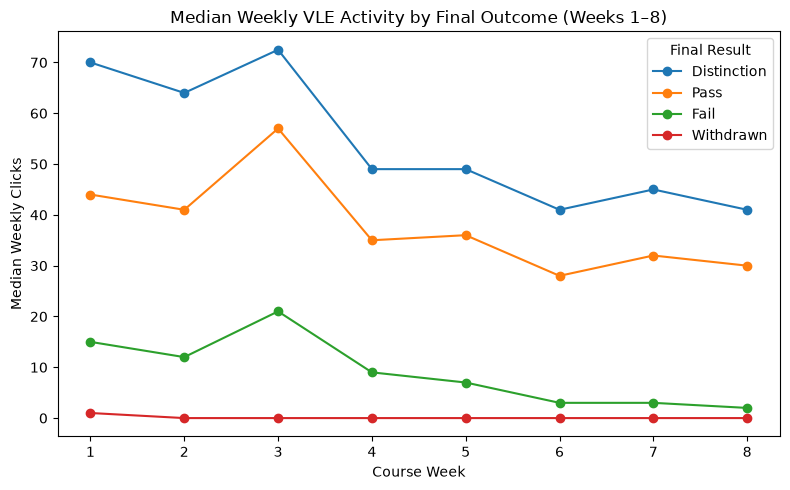

In [54]:
import matplotlib.pyplot as plt

plot_data = (
    weekly_activity_by_outcome
    .select(
        [
            "final_result",
            "course_week",
            "median_weekly_clicks",
        ]
    )
    .sort(["final_result", "course_week"])
)

outcome_order = ["Distinction", "Pass", "Fail", "Withdrawn"]

plt.figure(figsize=(8, 5))

for outcome in outcome_order:
    subset = plot_data.filter(pl.col("final_result") == outcome)
    plt.plot(
        subset["course_week"].to_list(),
        subset["median_weekly_clicks"].to_list(),
        marker="o",
        label=outcome,
    )

plt.title("Median Weekly VLE Activity by Final Outcome (Weeks 1–8)")
plt.xlabel("Course Week")
plt.ylabel("Median Weekly Clicks")
plt.xticks(range(1, 9))
plt.legend(title="Final Result")
plt.tight_layout()
plt.show()

这张图没问题，可以作为 3.5 VLE Activity Over Time 的核心图。

它清楚显示：

Distinction 在 Week 1–8 始终保持最高的 median weekly clicks；

Pass 次之；

Fail 的 activity 明显更低，并在 Week 4 后进一步下降；

Withdrawn 从 Week 2 开始 median weekly clicks 已经降为 0，说明至少一半的 withdrawn registrations 在这些 weeks 没有任何 VLE activity。

这里最后一点很重要：因为 median 是基于包含 0 的完整 registration-week grid 计算的，所以 Withdrawn = 0 不是缺失数据，也不是绘图问题，而是说明当周至少 50% 的 withdrawn registrations 没有 activity。

# 3.6 Implications for the Prediction Analysis

target 存在 class imbalance 和 module-level heterogeneity；

assessment participation 与 VLE engagement 在 outcome groups 之间有明显差异；

early weekly behavior 已经出现 separation；

后续所有 behavioral and assessment features 必须在 prediction cutoff 内构建，避免 temporal leakage